# Outline

What will be present in the Streamlit Page
- Chloropeth map
- WordCloud
- Some other analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
flats = pd.read_csv('../EDA/flats_new.csv',index_col=0)
houses = pd.read_csv('../EDA/houses_new.csv',index_col=0)


## Scatter Plots

In [3]:
# Flats

In [5]:
import os
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

def generate_location_coordinates(locations_list, output_filename="society_coordinates.csv"):
    """
    Inputs a list of housing societies/locations, automatically finds their 
    latitude and longitude coordinates, and saves the results to a CSV file.
    """
    # 1. Convert the input list into a clean pandas DataFrame
    df = pd.DataFrame({'Main Location': locations_list})
    
    # 2. Initialize the OpenStreetMap geocoding engine
    # 'user_agent' can be any unique string identifier for your app
    geolocator = Nominatim(user_agent="pk_property_coordinate_fetcher")
    
    # RateLimiter forces a 1-second delay between requests so OSM servers don't block you
    geocode_service = RateLimiter(geolocator.geocode, min_delay_seconds=1.0)
    
    latitudes = []
    longitudes = []
    
    print(f"Starting coordinate fetch for {len(locations_list)} locations...")
    
    # 3. Loop through each location and look up its coordinates
    for index, location in enumerate(locations_list):
        try:
            # Crucial: Adding contextual city/country suffix guarantees accurate local results
            search_query = f"{location}, Islamabad, Pakistan"
            
            print(f"[{index + 1}/{len(locations_list)}] Searching for: '{search_query}'")
            resolved_location = geocode_service(search_query)
            
            if resolved_location:
                latitudes.append(resolved_location.latitude)
                longitudes.append(resolved_location.longitude)
            else:
                # If "Location, Islamabad" fails, try fallback "Location, Pakistan" 
                # (Good for places right on the boundary line like Faisal Hills, Taxila/Rawalpindi)
                fallback_query = f"{location}, Pakistan"
                resolved_location = geocode_service(fallback_query)
                
                if resolved_location:
                    latitudes.append(resolved_location.latitude)
                    longitudes.append(resolved_location.longitude)
                else:
                    print(f"⚠️ Warning: Could not find coordinates for '{location}'")
                    latitudes.append(None)
                    longitudes.append(None)
                    
        except Exception as e:
            print(f"❌ Error querying '{location}': {e}")
            latitudes.append(None)
            longitudes.append(None)
            
    # 4. Attach the calculated coordinates back to our DataFrame
    df['Latitude'] = latitudes
    df['Longitude'] = longitudes
    
    # 5. Save the final DataFrame cleanly to a CSV file
    df.to_csv(output_filename, index=False, encoding='utf-8')
    print(f"\n All done! Coordinates saved successfully to: '{os.path.abspath(output_filename)}'")
    
    return df



In [6]:
location_lists = flats['Main Location'].unique()

In [7]:
df = generate_location_coordinates(location_lists)

Starting coordinate fetch for 81 locations...
[1/81] Searching for: 'Diplomatic Enclave, Islamabad, Pakistan'
[2/81] Searching for: 'Karakoram Diplomatic Enclave, Islamabad, Pakistan'
[3/81] Searching for: 'Bahria Enclave, Islamabad, Pakistan'
[4/81] Searching for: 'F-8, Islamabad, Pakistan'
[5/81] Searching for: 'Gulberg Greens, Islamabad, Pakistan'
[6/81] Searching for: 'Faisal Town Phase 1, Islamabad, Pakistan'
[7/81] Searching for: 'F-11, Islamabad, Pakistan'
[8/81] Searching for: 'GT Road, Islamabad, Pakistan'
[9/81] Searching for: 'DHA Phase 2, Islamabad, Pakistan'
[10/81] Searching for: 'Kashmir Highway, Islamabad, Pakistan'
[11/81] Searching for: 'E-11, Islamabad, Pakistan'
[12/81] Searching for: 'F-17, Islamabad, Pakistan'
[13/81] Searching for: 'G-11, Islamabad, Pakistan'
[14/81] Searching for: 'Top City 1, Islamabad, Pakistan'
[15/81] Searching for: 'Kuri Road, Islamabad, Pakistan'
[16/81] Searching for: 'DHA Phase 5, Islamabad, Pakistan'
[17/81] Searching for: 'Park View Ci

In [18]:
import pandas as pd

# 1. Load your newly saved Coordinates CSV (Your "Master Dictionary")
# (Make sure the filename matches what you saved it as earlier)
coords_df = pd.read_csv("flats_location_lat_long.csv")



print("--- Original Property Data (Missing Coordinates) ---")
print(flats.head(), "\n")

# ==========================================
# 3. THE MAGIC STEP: Merge the two datasets
# ==========================================
# This acts exactly like a VLOOKUP in Excel. 
# 'how="left"' ensures we don't lose any of our property data, even if a coordinate is missing.
final_df = pd.merge(
    flats, 
    coords_df[['Main Location', 'Latitude', 'Longitude']], # Only bring over the columns we need
    on='Main Location', 
    how='left'
)

print("--- Merged Data (Ready for Plotly) ---")
print(final_df.head())

# Optional: Find out if any locations failed to match so you can fix them
missing_coords = final_df[final_df['Latitude'].isna()]
if not missing_coords.empty:
    print("\n⚠️ Heads up! These locations are missing coordinates in your CSV:")
    print(missing_coords['Main Location'].tolist())

--- Original Property Data (Missing Coordinates) ---
                        Building                 Main Location  Type  \
7             Diplomatic Enclave            Diplomatic Enclave  Flat   
8   Karakoram Diplomatic Enclave  Karakoram Diplomatic Enclave  Flat   
9             Diplomatic Enclave            Diplomatic Enclave  Flat   
15               Cube Apartments                Bahria Enclave  Flat   
17                 The Centaurus                           F-8  Flat   

    Price(Cr)  Bath(s)  Area(Marla)  Bedroom(s)  \
7        7.20      2.0          6.5         2.0   
8       13.25      4.0         11.8         3.0   
9        5.40      3.0          7.3         3.0   
15       1.04      2.0          5.0         1.0   
17       5.75      1.0          3.9         1.0   

                                          Description  \
7   Luxurious 2-Bedroom Semi-Furnished Apartment f...   
8   Luxurious 3-Bedroom Fully Furnished Corner Apa...   
9   Details - 3 spacious bedrooms wi

In [21]:
final_df.isnull().sum()

Building                                 0
Main Location                            0
Type                                     0
Price(Cr)                                0
Bath(s)                                 21
Area(Marla)                              0
Bedroom(s)                              40
Description                              0
Amenities: Main Features               130
Amenities: Rooms                       198
Amenities: Healthcare Recreational     475
Amenities: Other Facilities            227
IsPrimeLoc                               0
SolarInstalled                           0
WaterBore                                0
CornerHouse                              0
luxury_type                              0
Built in year                          327
Parking Spaces                         236
Floor                                  604
Lobby in Building                      498
Elevators                              598
Service Elevators in Building          650
Floor in Bu

In [22]:
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import os

def fill_missing_coordinates(input_csv, output_csv):
    # 1. Load the existing CSV file
    try:
        df = pd.read_csv(input_csv)
    except FileNotFoundError:
        print(f"Error: Could not find '{input_csv}'. Make sure the file name is correct.")
        return

    # 2. Define the exact search corrections we discussed earlier
    name_corrections = {
        'Faisal Hills': 'Faisal Hills, Taxila, Pakistan',
        'Gulberg Residencia': 'Gulberg Residencia, Rawalpindi, Pakistan',
        'PAF Tarnol': 'PAF Housing Society, Islamabad, Pakistan',
        'MPCHS - Multi Gardens': 'Multi Gardens B-17, Islamabad, Pakistan',
        'Zaraj Housing Scheme': 'Zaraj Housing Society, Rawalpindi, Pakistan',
        'Margalla Hills-2': 'Margalla Hills, Islamabad, Pakistan',
        'Margalla View Housing Society': 'Margalla View Housing Society, D-17, Islamabad',
        'PWD Housing Scheme': 'PWD, Rawalpindi, Pakistan',
        'FECHS': 'FECHS E-11, Islamabad, Pakistan',
        'Gulberg Rabi Center': 'Rabi Center Gulberg, Islamabad, Pakistan',
        'FOECHS - Foreign Office Employees Society': 'FOECHS, Islamabad, Pakistan',
        'Canyon Views Cvrp': 'Canyon Views, Islamabad, Pakistan',
        'Gulberg Business Park': 'Gulberg Greens, Islamabad, Pakistan'
    }

    # 3. Initialize the Geocoder
    geolocator = Nominatim(user_agent="pk_property_coordinate_fixer")
    geocode_service = RateLimiter(geolocator.geocode, min_delay_seconds=1.0)

    # 4. Find all rows where Latitude or Longitude is blank (NaN)
    missing_mask = df['Latitude'].isna() | df['Longitude'].isna()
    missing_count = missing_mask.sum()
    
    if missing_count == 0:
        print("No missing coordinates found! Your file is already complete.")
        return df

    print(f"Found {missing_count} missing locations. Attempting to fix them now...\n")

    # 5. Loop ONLY through the rows that are missing data
    for index, row in df[missing_mask].iterrows():
        original_name = row['Main Location']
        
        # Check if we have an optimized search term for this location
        if original_name in name_corrections:
            search_query = name_corrections[original_name]
            print(f"Fixing '{original_name}' -> Searching for: '{search_query}'")
        else:
            # If it's missing but not in our list, try a general Pakistan fallback
            search_query = f"{original_name}, Pakistan"
            print(f"Fixing '{original_name}' -> Searching for: '{search_query}'")

        try:
            # Fetch the new coordinates
            result = geocode_service(search_query)
            
            if result:
                # Update the dataframe with the new numbers
                df.at[index, 'Latitude'] = result.latitude
                df.at[index, 'Longitude'] = result.longitude
                print(f"   ✅ Success! Found: {result.latitude}, {result.longitude}")
            else:
                print("   ❌ Still failed to find coordinates.")
                
        except Exception as e:
            print(f"   ⚠️ Error during search: {e}")

    # 6. Save the updated dataframe to a new CSV file
    df.to_csv(output_csv, index=False)
    print(f"\nAll updates complete! Fully populated file saved as: '{os.path.abspath(output_csv)}'")
    
    return df

# ==========================================
# HOW TO RUN IT
# ==========================================
if __name__ == "__main__":
    # Replace 'society_coordinates.csv' with the actual name of your file
    input_file = 'flats_location_lat_long.csv' 
    output_file = 'flats_location_lat_long_fixed.csv'
    
    updated_df = fill_missing_coordinates(input_file, output_file)

Found 13 missing locations. Attempting to fix them now...

Fixing 'Faisal Hills' -> Searching for: 'Faisal Hills, Taxila, Pakistan'
   ❌ Still failed to find coordinates.
Fixing 'Gulberg Residencia' -> Searching for: 'Gulberg Residencia, Rawalpindi, Pakistan'
   ❌ Still failed to find coordinates.
Fixing 'PAF Tarnol' -> Searching for: 'PAF Housing Society, Islamabad, Pakistan'
   ❌ Still failed to find coordinates.
Fixing 'MPCHS - Multi Gardens' -> Searching for: 'Multi Gardens B-17, Islamabad, Pakistan'
   ❌ Still failed to find coordinates.
Fixing 'Zaraj Housing Scheme' -> Searching for: 'Zaraj Housing Society, Rawalpindi, Pakistan'
   ✅ Success! Found: 33.5137405, 73.1517139
Fixing 'Margalla Hills-2' -> Searching for: 'Margalla Hills, Islamabad, Pakistan'
   ✅ Success! Found: 33.7606136, 73.0244561
Fixing 'Margalla View Housing Society' -> Searching for: 'Margalla View Housing Society, D-17, Islamabad'
   ❌ Still failed to find coordinates.
Fixing 'PWD Housing Scheme' -> Searching f

In [14]:
location_lists_houses = houses['Main Location'].unique()

In [15]:
df_houses = generate_location_coordinates(location_lists_houses,'houses_location_lat_long.csv')

Starting coordinate fetch for 116 locations...
[1/116] Searching for: 'D-12, Islamabad, Pakistan'
[2/116] Searching for: 'Bahria Enclave, Islamabad, Pakistan'
[3/116] Searching for: 'FECHS, Islamabad, Pakistan'
⚠️ Warning: Could not find coordinates for 'FECHS'
[4/116] Searching for: 'Faisal Town Phase 1, Islamabad, Pakistan'
[5/116] Searching for: 'G-13, Islamabad, Pakistan'
[6/116] Searching for: 'MPCHS - Multi Gardens, Islamabad, Pakistan'
⚠️ Warning: Could not find coordinates for 'MPCHS - Multi Gardens'
[7/116] Searching for: 'B-17, Islamabad, Pakistan'
[8/116] Searching for: 'D-17, Islamabad, Pakistan'
[9/116] Searching for: 'CBR Town Phase 1, Islamabad, Pakistan'
[10/116] Searching for: 'Soan Garden, Islamabad, Pakistan'
[11/116] Searching for: 'DHA Phase 2, Islamabad, Pakistan'
[12/116] Searching for: 'E-7, Islamabad, Pakistan'
[13/116] Searching for: 'G-11, Islamabad, Pakistan'
[14/116] Searching for: 'Naval Anchorage, Islamabad, Pakistan'
[15/116] Searching for: 'G-9, Islamab

In [23]:
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import os

def fill_missing_coordinates(input_csv, output_csv):
    # 1. Load the existing CSV file
    try:
        df = pd.read_csv(input_csv)
    except FileNotFoundError:
        print(f"Error: Could not find '{input_csv}'. Make sure the file name is correct.")
        return

    # 2. Define the exact search corrections we discussed earlier
    name_corrections = {
        'Faisal Hills': 'Faisal Hills, Taxila, Pakistan',
        'Gulberg Residencia': 'Gulberg Residencia, Rawalpindi, Pakistan',
        'PAF Tarnol': 'PAF Housing Society, Islamabad, Pakistan',
        'MPCHS - Multi Gardens': 'Multi Gardens B-17, Islamabad, Pakistan',
        'Zaraj Housing Scheme': 'Zaraj Housing Society, Rawalpindi, Pakistan',
        'Margalla Hills-2': 'Margalla Hills, Islamabad, Pakistan',
        'Margalla View Housing Society': 'Margalla View Housing Society, D-17, Islamabad',
        'PWD Housing Scheme': 'PWD, Rawalpindi, Pakistan',
        'FECHS': 'FECHS E-11, Islamabad, Pakistan',
        'Gulberg Rabi Center': 'Rabi Center Gulberg, Islamabad, Pakistan',
        'FOECHS - Foreign Office Employees Society': 'FOECHS, Islamabad, Pakistan',
        'Canyon Views Cvrp': 'Canyon Views, Islamabad, Pakistan',
        'Gulberg Business Park': 'Gulberg Greens, Islamabad, Pakistan'
    }

    # 3. Initialize the Geocoder
    geolocator = Nominatim(user_agent="pk_property_coordinate_fixer")
    geocode_service = RateLimiter(geolocator.geocode, min_delay_seconds=1.0)

    # 4. Find all rows where Latitude or Longitude is blank (NaN)
    missing_mask = df['Latitude'].isna() | df['Longitude'].isna()
    missing_count = missing_mask.sum()
    
    if missing_count == 0:
        print("No missing coordinates found! Your file is already complete.")
        return df

    print(f"Found {missing_count} missing locations. Attempting to fix them now...\n")

    # 5. Loop ONLY through the rows that are missing data
    for index, row in df[missing_mask].iterrows():
        original_name = row['Main Location']
        
        # Check if we have an optimized search term for this location
        if original_name in name_corrections:
            search_query = name_corrections[original_name]
            print(f"Fixing '{original_name}' -> Searching for: '{search_query}'")
        else:
            # If it's missing but not in our list, try a general Pakistan fallback
            search_query = f"{original_name}, Pakistan"
            print(f"Fixing '{original_name}' -> Searching for: '{search_query}'")

        try:
            # Fetch the new coordinates
            result = geocode_service(search_query)
            
            if result:
                # Update the dataframe with the new numbers
                df.at[index, 'Latitude'] = result.latitude
                df.at[index, 'Longitude'] = result.longitude
                print(f"   ✅ Success! Found: {result.latitude}, {result.longitude}")
            else:
                print("   ❌ Still failed to find coordinates.")
                
        except Exception as e:
            print(f"   ⚠️ Error during search: {e}")

    # 6. Save the updated dataframe to a new CSV file
    df.to_csv(output_csv, index=False)
    print(f"\nAll updates complete! Fully populated file saved as: '{os.path.abspath(output_csv)}'")
    
    return df

# ==========================================
# HOW TO RUN IT
# ==========================================
if __name__ == "__main__":
    # Replace 'society_coordinates.csv' with the actual name of your file
    input_file = 'houses_location_lat_long.csv' 
    output_file = 'houses_location_lat_long_fixed.csv'
    
    updated_df = fill_missing_coordinates(input_file, output_file)

Found 19 missing locations. Attempting to fix them now...

Fixing 'FECHS' -> Searching for: 'FECHS E-11, Islamabad, Pakistan'
   ❌ Still failed to find coordinates.
Fixing 'MPCHS - Multi Gardens' -> Searching for: 'Multi Gardens B-17, Islamabad, Pakistan'
   ❌ Still failed to find coordinates.
Fixing 'Margalla View Housing Society' -> Searching for: 'Margalla View Housing Society, D-17, Islamabad'
   ❌ Still failed to find coordinates.
Fixing 'DHA Valley' -> Searching for: 'DHA Valley, Pakistan'
   ❌ Still failed to find coordinates.
Fixing 'Zaraj Housing Scheme' -> Searching for: 'Zaraj Housing Society, Rawalpindi, Pakistan'
   ✅ Success! Found: 33.5137405, 73.1517139
Fixing 'Gulberg Residencia' -> Searching for: 'Gulberg Residencia, Rawalpindi, Pakistan'
   ❌ Still failed to find coordinates.
Fixing 'PWD Housing Scheme' -> Searching for: 'PWD, Rawalpindi, Pakistan'
   ✅ Success! Found: 33.5766182, 73.1515677
Fixing 'Airport Green Garden' -> Searching for: 'Airport Green Garden, Pakis

In [30]:


# 2. Load the CSV file you just created that contains the coordinates
coords_df = pd.read_csv("flats_location_lat_long_fixed.csv")

# 3. Merge them together based on the 'Main Location' column
# Using how='left' ensures that no data from your original dataset is accidentally deleted, 
# even if a coordinate happens to be missing.
final_df = pd.merge(flats, coords_df, on='Main Location', how='left')

# 4. (Optional) Check to make sure it worked
print(final_df.head())

# 5. Save your master dataset so it's ready for Plotly!
final_df.to_csv("flats_lat_long.csv", index=False)

                       Building                 Main Location  Type  \
0            Diplomatic Enclave            Diplomatic Enclave  Flat   
1  Karakoram Diplomatic Enclave  Karakoram Diplomatic Enclave  Flat   
2            Diplomatic Enclave            Diplomatic Enclave  Flat   
3               Cube Apartments                Bahria Enclave  Flat   
4                 The Centaurus                           F-8  Flat   

   Price(Cr)  Bath(s)  Area(Marla)  Bedroom(s)  \
0       7.20      2.0          6.5         2.0   
1      13.25      4.0         11.8         3.0   
2       5.40      3.0          7.3         3.0   
3       1.04      2.0          5.0         1.0   
4       5.75      1.0          3.9         1.0   

                                         Description  \
0  Luxurious 2-Bedroom Semi-Furnished Apartment f...   
1  Luxurious 3-Bedroom Fully Furnished Corner Apa...   
2  Details - 3 spacious bedrooms with modern amen...   
3  Cube Apartment One Bedroom Apartment Beautifu

# WordCloud

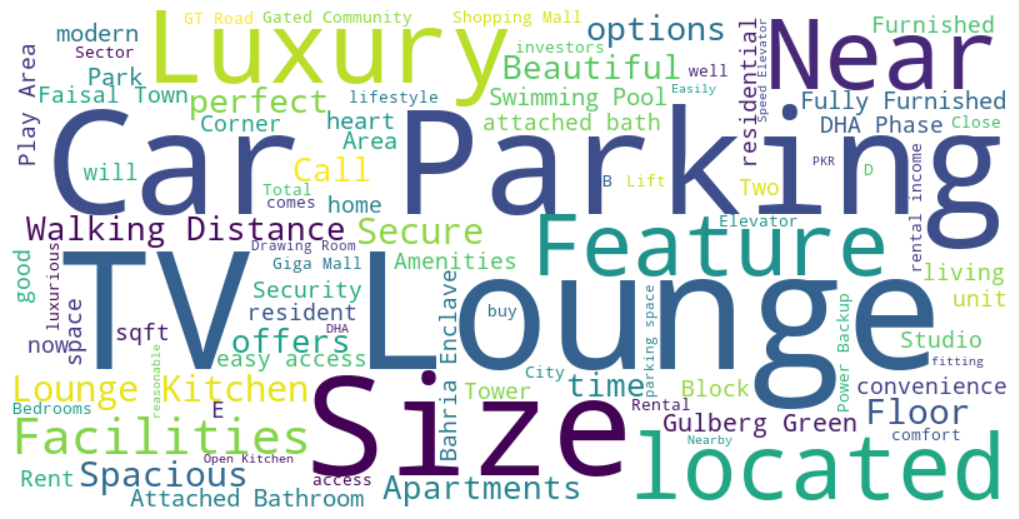

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# 1. Load your data (replace with your actual file path)
# df = pd.read_csv('your_real_estate_data.csv')

# Crucial Step: Combine all descriptions into one massive string and drop missing values
text = " ".join(desc for desc in flats['Description'].dropna())

# 2. Fine-tune your stopwords
# We start with default English stopwords (the, and, a, etc.)
custom_stopwords = set(STOPWORDS)

# Real estate descriptions often need extra filtering to be useful.
# Add words here that you want to ignore because they are too generic.
real_estate_noise = {
    'sale', 'available', 'detail', 'project', 'option', 'best', 'prime', 
    'location', 'ideal', 'contact', 'us', 'please', 'today', 'make', 'one', 
    'view', 'brand', 'new', 'looking', 'find', 'feel', 'free', 'investment', 
    'investor', 'opportunity', 'ready', 'value', 'quality', 'high', 'type',
    'real', 'estate', 'price', 'rs', 'information', 'visit', 'need', 'offer',
    'offering', 'come', 'enjoy','apartment','islamabad','details','property','flat','square','feet','bedroom',
    'bed','sq','ft','building'
}
custom_stopwords.update(real_estate_noise)

# 3. Configure the Word Cloud
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',  # 'black' also looks sharp depending on preference
    stopwords=custom_stopwords,
    min_font_size=10,
    colormap='viridis'         # Try 'plasma', 'inferno', or 'coolwarm' for different vibes
).generate(text)

# 4. Display the visual
plt.figure(figsize=(10, 5), facecolor=None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")  # Hides the x and y axis lines
plt.tight_layout(pad=0)

plt.show()

## Areas with most Prices and Area

<Axes: xlabel='Main Location', ylabel='Bedroom(s)'>

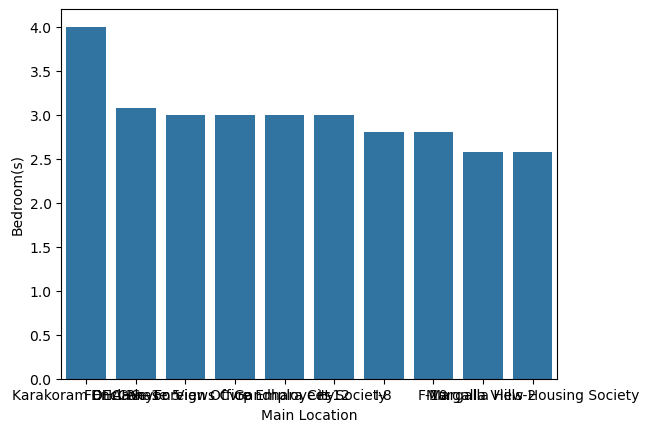

In [11]:
type_of_groupby = 'Bedroom(s)'


sns.barplot(flats.groupby('Main Location')[type_of_groupby].mean().sort_values(ascending=False).head(10))

In [36]:
houses.iloc[:2,5:-5]

,Area(Marla),Bedroom(s),Description,Amenities: Main Features,Amenities: Rooms,Amenities: Healthcare Recreational,Amenities: Other Facilities,IsPrimeLoc,SolarInstalled,WaterBore,...,Floor in Building,Bedrooms,Bathrooms,Servant Quarters,Kitchens,Store Rooms,Swimming Pool,Sauna,Jacuzzi,Security Staff
0,10.0,6.0,10 MARLA LUXXARY BRAND NEW PARK FACE AVAILABLE...,"Built in year, Parking Spaces: 4, Double Glaze...","Bedrooms: 6, Bathrooms: 8, Servant Quarters: 2...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Security Staff, Other Facilities",False,False,False,...,NaN,6.0,8.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0
1,4.4,3.0,4.44 Marla Single Unit Luxury corner House wit...,"Built in year, Parking Spaces: 3, Double Glaze...","Bedrooms: 3, Bathrooms: 4, Servant Quarters: 1...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Security Staff, Other Facilities",False,False,True,...,NaN,3.0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [38]:
houses['Amenities: Main Features'][0]

'Built in year, Parking Spaces: 4, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floors: 2, Other Main Features'

In [42]:
flats['Amenities: Main Features'][8]

'Lobby in Building, Central Air Conditioning, Central Heating, Waste Disposal, Service Elevators in Building'

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

In [50]:
house_pool = houses.copy()

house_pool["Price_Per_Marla"] = (
    house_pool["Price(Cr)"] / house_pool["Area(Marla)"]
)

# 2. Structural Space & Utility Score (Sum of physical assets unique to a house)
structural_features = [
    "SolarInstalled",
    "WaterBore",
    "CornerHouse",
    "IsPrimeLoc",
    "Servant Quarters",
    "Kitchens",
    "Store Rooms",
]
# Fill any missing values in structural specs with 0 before math operations
house_pool[structural_features] = house_pool[structural_features].fillna(0)

# 3. Text Normalization
house_pool["Description_Cleaned"] = (
    house_pool["Description"].fillna("").str.lower()
)

In [55]:
house_pool[structural_features]  = house_pool[structural_features].fillna(0)

In [56]:
# --- CROSS-LOCATION HOUSE RECOMMENDER ---
def recommend_alternative_luxury_houses(target_id, top_n=3):
    # Isolate the target house row
    target_row = house_pool.iloc[[target_id]]
    target = target_row.iloc[0]

    # Force cross-location discovery by filtering out the target house's own exact Main Location
    alternative_houses = house_pool[
        house_pool["Main Location"] != target["Main Location"]
    ].copy()

    if alternative_houses.empty:
        return (
            "No houses available in alternative locations for comparison currently."
        )

    # PASS 1: Calculate Spatial Configuration & Value Similarity
    scaler = MinMaxScaler()
    # Combining pricing efficiency with physical dimensions and layout capacities
    config_cols = [
        "Price_Per_Marla",
        "Area(Marla)",
        "Bedrooms",
        "Bathrooms",
        "Kitchens",
    ]

    scaled_alt_configs = scaler.fit_transform(alternative_houses[config_cols])
    scaled_target_configs = scaler.transform([target[config_cols]])

    sim_config_and_value = cosine_similarity(
        scaled_target_configs, scaled_alt_configs
    ).flatten()

    # PASS 2: Calculate Independent Structural Perks Similarity
    # This evaluates matches on premium flags like Solar, Corner House, or Water Bores
    alt_structures = alternative_houses[structural_features].values
    target_structure = np.array([target[structural_features].values])

    sim_structural_perks = cosine_similarity(
        target_structure, alt_structures
    ).flatten()

    # PASS 3: Extract Construction & Intent Vibe (TF-IDF)
    # Primed to catch double vs single unit layout intents and premium building materials
    house_vocabulary = [
        "double unit",
        "single unit",
        "brand new",
        "designer",
        "park face",
        "open view",
        "rented out",
        "rental income",
        "imported fittings",
        "porta",
        "sonex",
    ]

    tfidf = TfidfVectorizer(vocabulary=house_vocabulary)
    tfidf_alt = tfidf.fit_transform(alternative_houses["Description_Cleaned"])
    tfidf_target = tfidf.transform([target["Description_Cleaned"]])

    sim_house_vibe = cosine_similarity(tfidf_target, tfidf_alt).flatten()

    # PASS 4: Balanced Combination Matrix
    # Configuration/Value (40%), Core Perks (35%), Text Architecture/Vibe (25%)
    final_scores = (
        (sim_config_and_value * 0.40)
        + (sim_structural_perks * 0.35)
        + (sim_house_vibe * 0.25)
    )

    alternative_houses["similarity_score"] = final_scores
    recommendations = alternative_houses.sort_values(
        by="similarity_score", ascending=False
    )

    return recommendations[
        [
            "Main Location",
            "Real Location",
            "Price(Cr)",
            "Area(Marla)",
            "Price_Per_Marla",
            "Bedrooms",
            "Kitchens",
            "SolarInstalled",
            "WaterBore",
            "similarity_score",
        ]
    ].head(top_n)


# Execute recommendation engine using index 1 (10 Marla House in D-12)
recommend_alternative_luxury_houses(target_id=1, top_n=3)

C:\Users\Wajih\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


ValueError: Input contains NaN.